In [1]:
import os
os.chdir('../')

In [2]:
!ls samplings/DiT/1.5/200/Euler/100/paper_0

0.pt   1.pt   2.pt   3.pt   4.pt   5.pt   6.pt	 7.pt	8.pt   9.pt
10.pt  20.pt  30.pt  40.pt  50.pt  60.pt  70.pt  80.pt	90.pt  config.json
11.pt  21.pt  31.pt  41.pt  51.pt  61.pt  71.pt  81.pt	91.pt
12.pt  22.pt  32.pt  42.pt  52.pt  62.pt  72.pt  82.pt	92.pt
13.pt  23.pt  33.pt  43.pt  53.pt  63.pt  73.pt  83.pt	93.pt
14.pt  24.pt  34.pt  44.pt  54.pt  64.pt  74.pt  84.pt	94.pt
15.pt  25.pt  35.pt  45.pt  55.pt  65.pt  75.pt  85.pt	95.pt
16.pt  26.pt  36.pt  46.pt  56.pt  66.pt  76.pt  86.pt	96.pt
17.pt  27.pt  37.pt  47.pt  57.pt  67.pt  77.pt  87.pt	97.pt
18.pt  28.pt  38.pt  48.pt  58.pt  68.pt  78.pt  88.pt	98.pt
19.pt  29.pt  39.pt  49.pt  59.pt  69.pt  79.pt  89.pt	99.pt


In [3]:
import torch
weights = torch.load('samplings/DiT/1.5/200/Euler/100/paper_0/0.pt')
weights['preds'].shape

torch.Size([200, 2, 4, 32, 32])

In [ ]:
import torch, matplotlib.pyplot as plt

base = 'samplings/DiT/1.5/200/Euler/100/paper_0'
N = 100  # 0.pt ~ 99.pt
stride = 1
pred_index = 0 # 0 : data, 1 : noise

# ----- 곡률 (비균일 x, 다중 시계열 Y: [S, M]) -----
def kappa_many(x, Y, eps=1e-12):
    x = x.double().flatten()
    Y = Y.double()                # [S, M]
    S, M = Y.shape

    Y1 = torch.empty(S, M, dtype=torch.double)
    Y2 = torch.empty(S, M, dtype=torch.double)

    # 1차 미분
    Y1[1:-1] = (Y[2:] - Y[:-2]) / (x[2:] - x[:-2]).unsqueeze(1)
    Y1[0]    = (Y[1] - Y[0])     / (x[1] - x[0])
    Y1[-1]   = (Y[-1] - Y[-2])   / (x[-1] - x[-2])

    # 2차 미분(비균일 3점)
    h1 = (x[1:-1] - x[:-2]).unsqueeze(1)
    h2 = (x[2:]   - x[1:-1]).unsqueeze(1)
    Y2[1:-1] = 2*( h2*Y[:-2] - (h1+h2)*Y[1:-1] + h1*Y[2:] ) / (h1*h2*(h1+h2))
    Y2[0], Y2[-1] = Y2[1], Y2[-2]

    denom = (1 + Y1**2).pow(1.5).clamp_min(eps)
    K = (Y2.abs() / denom)        # [S, M]
    return K.mean(dim=1)          # 공간 평균 → [S]

# ----- 축(도메인) 정의: 0.pt에서 -----
w0 = torch.load(f'{base}/0.pt', map_location='cpu')
S  = w0['preds'][::stride, pred_index].shape[0]
t  = w0['timesteps'][:-1:stride].double()
alpha = w0['alphas'][:-1:stride].double()
sigma = w0['sigmas'][:-1:stride].double()
logsnr = torch.log((alpha**2)/(sigma**2))
rho    = sigma / alpha
a_over_s = alpha / sigma.clamp_min(1e-12)   # 추가: alpha/sigma

# ----- 평균 누적 -----
k_t_sum  = torch.zeros(S, dtype=torch.double)
k_l_sum  = torch.zeros(S, dtype=torch.double)
k_r_sum  = torch.zeros(S, dtype=torch.double)
k_as_sum = torch.zeros(S, dtype=torch.double)  # 추가

for i in range(N):
    pt_file = f'{base}/{i}.pt'
    if not os.path.exists(pt_file):
        continue
    w = torch.load(pt_file, map_location='cpu')
    Y = w['preds'][::stride, pred_index].double().reshape(S, -1)   # [S, C*H*W]
    k_t_sum  += kappa_many(t,        Y)
    k_l_sum  += kappa_many(logsnr,   Y)
    k_r_sum  += kappa_many(rho,      Y)
    k_as_sum += kappa_many(a_over_s, Y)  # 추가
N = i

k_t  = (k_t_sum /N).clamp_min(1e-12)
k_l  = (k_l_sum /N).clamp_min(1e-12)
k_r  = (k_r_sum /N).clamp_min(1e-12)
k_as = (k_as_sum/N).clamp_min(1e-12)     # 추가



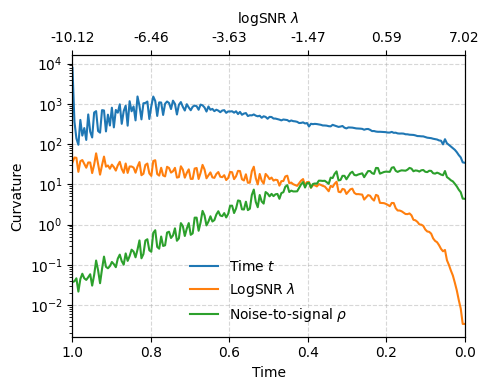

In [6]:
# ----- 한 그래프에 겹쳐 그리기 (멀티 틱 + 상단 λ 축) -----
import matplotlib.pyplot as plt

x = torch.linspace(0, 1, S)  # 진행률(0→1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, k_t, label='Time $t$', linewidth=1.5)
ax.plot(x, k_l, label='LogSNR $\\lambda$', linewidth=1.5)   # k_l은 진행률 순서대로 가정
ax.plot(x, k_r, label='Noise-to-signal $\\rho$', linewidth=1.5)

ax.set_yscale('log')
ax.set_xlim(0, 1)

# 하단: Time t (coarse ticks)
n = 6
idx = torch.linspace(0, S-1, steps=n).round().long()
xpos = torch.linspace(0, 1, steps=n).tolist()
ax.set_xticks(xpos)
ax.set_xticklabels([f'{t[i].item():.1f}' for i in idx])
ax.set_xlabel('Time')

# 상단: logSNR λ (같은 진행률 위치에 매핑)
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(xpos)
ax_top.set_xticklabels([f'{logsnr[i].item():.2f}' for i in idx])
ax_top.set_xlabel('logSNR $\\lambda$', labelpad=6)
# λ를 역방향(큰→작은)으로 보고 싶으면 아래 한 줄 추가
# ax_top.invert_xaxis()

ax.set_ylabel('Curvature')
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


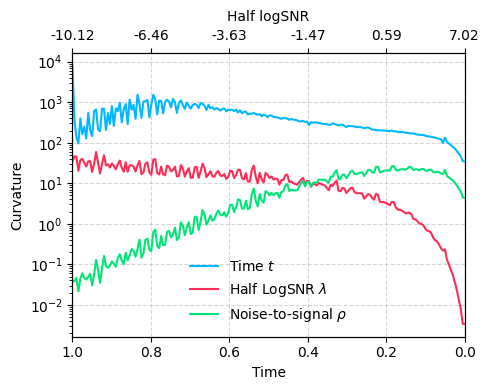

In [8]:
# ----- 한 그래프에 겹쳐 그리기 (멀티 틱 + 상단 λ 축) -----
import torch
import matplotlib.pyplot as plt

# 지정 색상
C_T = "#00B8FF"   # Time t
C_L = "#FF2D55"   # LogSNR λ
C_R = "#00E676"   # Noise-to-signal ρ

x = torch.linspace(0, 1, S)  # 진행률(0→1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, k_t, label='Time $t$', linewidth=1.5, color=C_T)
ax.plot(x, k_l, label='Half LogSNR $\\lambda$', linewidth=1.5, color=C_L)   # k_l은 진행률 순서대로 가정
ax.plot(x, k_r, label='Noise-to-signal $\\rho$', linewidth=1.5, color=C_R)

ax.set_yscale('log')
ax.set_xlim(0, 1)

# 하단: Time t (coarse ticks)
n = 6
idx = torch.linspace(0, S-1, steps=n).round().long()
xpos = torch.linspace(0, 1, steps=n).tolist()
ax.set_xticks(xpos)
ax.set_xticklabels([f'{t[i].item():.1f}' for i in idx])
ax.set_xlabel('Time')

# 상단: logSNR λ (같은 진행률 위치에 매핑)
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(xpos)
ax_top.set_xticklabels([f'{logsnr[i].item():.2f}' for i in idx])
ax_top.set_xlabel('Half logSNR', labelpad=6)
# λ를 역방향(큰→작은)으로 보고 싶으면 아래 한 줄 추가
# ax_top.invert_xaxis()

ax.set_ylabel('Curvature')
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
